# LAPD crimes database: 2010-present

### Import data tools

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import geojson
import json
import jenkspy
import numpy as np
from earthpy import clip as cl
from altair import datum
import weightedcalcs as wc
import altair as alt
alt.renderers.enable('notebook')
import altair_latimes as lat
alt.themes.register('latimes', lat.theme)
alt.themes.enable('latimes')
pd.options.display.max_columns = 50
pd.options.display.max_rows = 1000

### Read crimes CSV downloaded from LA City data portal

In [2]:
# https://data.lacity.org/A-Safe-City/Crime-Data-from-2010-to-Present/63jg-8b9z
src = pd.read_csv('/Users/mhustiles/data/data/LA/Crime_Data_from_2010_to_Present.csv')

In [3]:
crimes = src

In [4]:
crimes.columns = crimes.columns.str.strip().str.lower()\
.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

### These data are super messy...

In [5]:
crimes.rename(columns = { 
'dr_no':'record_id',
'date_rptd':'date_reported',
'date_occ':'date_occurred',
'time_occ':'time_occurred',
'area':'division',
'area_name':'division_name',
'rpt_dist_no':'reporting_district',
'part_1-2':'part_type',
'crm_cd':'crime_code',
'crm_cd_desc':'crime_code_description',
'mocodes':'modus_operandi_code',
'vict_age':'victim_age',
'vict_sex':'victim_sex',
'vict_descent':'victim_descent',
'premis_cd':'premises_code',
'premis_desc':'premises_description',
'weapon_used_cd':'weapon_code',
'weapon_desc':'weapon_description',
'status':'status_code',
'status_desc':'status_code_description',
'crm_cd_1':'crm_cd_1',
'crm_cd_2':'crm_cd_2',
'crm_cd_3':'crm_cd_3',
'crm_cd_4':'crm_cd_4',
'location':'address',
'cross_street':'cross_street',
'lat':'latitude',
'lon':'longitude',
 }, inplace = True)

### ... contunued

In [6]:
crimes['date_reported'] = crimes['date_reported'].str.replace(' 12:00:00 AM','')
crimes['date_occurred'] = crimes['date_occurred'].str.replace(' 12:00:00 AM','')
crimes['date_occurred'] = pd.to_datetime(crimes['date_occurred'], format='%m/%d/%Y')
crimes['year'] = crimes['date_occurred'].dt.year
crimes['quarter'] = crimes['date_occurred'].dt.quarter
crimes['day'] = crimes['date_occurred'].dt.day
crimes['month'] = crimes['date_occurred'].dt.month
crimes['weekday'] = crimes['date_occurred'].dt.weekday_name
crimes['monthname'] = crimes['date_occurred'].dt.month_name()

In [7]:
crimes[[ 'record_id', 
    'time_occurred', 
    'division', 
    'reporting_district', 
    'part_type',
    'crm_cd_1',
    'crm_cd_2',
    'crm_cd_3',
    'crm_cd_4',
    'crime_code', 
    'premises_code', 
    'weapon_code',
    'year',
    'quarter',
    'day',
    'month', ]] = crimes[[
    'record_id', 
    'time_occurred', 
    'division', 
    'reporting_district', 
    'part_type',
    'crm_cd_1',
    'crm_cd_2',
    'crm_cd_3',
    'crm_cd_4',
    'crime_code', 
    'premises_code', 
    'weapon_code',
    'year',
    'quarter',
    'day',
    'month',]].astype(str)

In [8]:
descent_recode = { 'A':"Asian",'B':"Black",'C':"Asian",'D':"Asian",'F':"Asian",'G':"Asian",\
                 'H':"Hispanic",'I':"American Indian/Alaskan Native",'J':"Asian",\
                 'K':"Asian",'L':"Asian",'O':"Other",'P':"Asian",'S':"Asian",\
                 'U':"Asian",'V':"Asian",'W':"White",'X':"Other",'Z':"Asian" }

In [9]:
crimes['descent_description'] = crimes['victim_descent'].map(descent_recode)

In [10]:
victim_sex_recode = { 'F':"Female",'M':"Male",'X':"Unknown",'-':"Unknown",'N':"Unknown",'H':"Unknown" }

In [11]:
crimes['victim_sex'] = crimes['victim_sex'].map(victim_sex_recode)

In [12]:
crimes['premises_code'] = crimes['premises_code'].str.replace('.0','', regex=False)
crimes['premises_code'] = crimes['premises_code'].str.replace('.0','', regex=False)
crimes['crm_cd_1'] = crimes['crm_cd_1'].str.replace('.0','', regex=False)
crimes['crm_cd_2'] = crimes['crm_cd_2'].str.replace('.0','', regex=False)

In [13]:
crimes['premises_description'] = crimes['premises_description'].str.capitalize()
crimes['crime_code_description'] = crimes['crime_code_description'].str.capitalize()
crimes['weapon_description'] = crimes['weapon_description'].str.capitalize()

In [14]:
monthnames = ['January','February','March','April','May','June','July','August','September','October','November','December']

In [15]:
crimes['time_occurred'] = crimes['time_occurred'].str.replace('.0','', regex=False)
crimes['time_occurred'] = crimes['time_occurred'].str.zfill(4)
crimes['hour'] = crimes['time_occurred'].str[:2]
crimes['minute'] = crimes['time_occurred'].str[2:]
crimes = crimes[crimes['hour'] != '0n']
crimes = crimes[crimes['hour'] != '24']

In [16]:
homicides = crimes[crimes['crime_code_description'].str.contains('CRIMINAL HOMICIDE', na=False)]

---

## Now that it's clean, what can we learn from this data?

### Share of crimes by UCR type

In [17]:
crimes['part_type'].value_counts('normalize').round(3)*100

1    55.4
2    44.6
Name: part_type, dtype: float64

In [18]:
cases_grouped = crimes.groupby(['crime_code_description', 'part_type', 'victim_sex'])\
.agg('size').reset_index(name='total').sort_values(by='total', ascending=False)

### Cases involving suspects or victimes defined by LAPD as 'homeless'

In [19]:
mocrimes = crimes.dropna(subset=['modus_operandi_code'])

In [20]:
mocodes = pd.read_csv('mo_codes.csv')
mocodes.head()

,mo_code,mo_code_description
0,0100,Suspect Impersonate
1,0101,Aid victim
2,0102,Blind
3,0103,Crippled
4,0104,Customer


### Isolating just cases involving homeless people

In [21]:
# MO Code 1218 is to be used when a victim is homeless
# MO Code 2004 is to be used when a suspect is homeless
mocodes_homeless = mocodes[mocodes['mo_code_description'].str.lower().str.contains('homeless')]
mocodes_homeless.head()

,mo_code,mo_code_description
361,1218,Victim was Homeless/Transient
521,2004,Suspect is homeless/transient


### Limit homeless crime data to recent years to account for LAPD coding priorities

In [22]:
homeless_dates = ['2017', '2018', '2019']

### Various filters filters for homeless residents

In [23]:
homeless_victims = crimes[(crimes['modus_operandi_code'].str.contains('1218', na=False)) \
                          & (crimes['year'].isin(homeless_dates))]

In [24]:
homeless_suspects = crimes[(crimes['modus_operandi_code'].str.contains('2004', na=False)) \
                           & (crimes['year'].isin(homeless_dates))]

In [25]:
homeless_homicides = homeless_victims[(homeless_victims['crime_code_description']\
                    .str.contains('Criminal homicide', na=False))\
                    & (homeless_victims['year'].isin(homeless_dates))]

In [26]:
homeless_victims_women = homeless_victims[homeless_victims['victim_sex'] == 'F']

---

## Geography

### Read city of Los Angeles boundary file

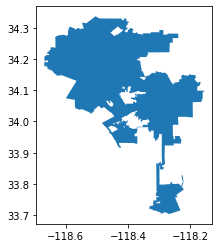

In [27]:
la = gpd.read_file('input/la_city_boundary/la_city_boundary_1570551157861.geojson')
la.plot()

In [67]:
# http://geohub.lacity.org/datasets/c493f3d44e97482e90ce9355019b1349_158
shelters_src = gpd.read_file('input/Homeless_Shelters_and_Services/Homeless_Shelters_and_Services.shp')

In [68]:
shelters = shelters_src[shelters_src['latitude'] > 28]

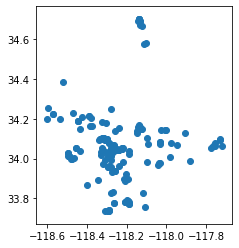

In [69]:
shelters.plot()

In [70]:
shelters.to_file('output/la_shelters.geojson', driver='GeoJSON')

In [71]:
shelters.head(2)

,OBJECTID,source,ext_id,cat1,cat2,cat3,org_name,Name,addrln1,addrln2,city,state,hours,phones,email,url,info1,info2,post_id,descriptio,zip,link,use_type,latitude,longitude,date_updat,dis_status,POINT_X,POINT_Y,geometry
0,149780041,211,None,Social Services,Homeless Shelters and Services,None,None,Children's Hosptial Los Angeles - High Risk Yo...,5000 W Sunset Blvd,4th Fl.,Los Angeles,CA,"Monday through Friday, 8:30am to 5:00pm. Clin...","Administrative (323) 361-2390, Appointments Se...",None,www.childrenshospitalla.org/site/c.ipINKTOAJsG...,None,None,947,The agency provides health services and homele...,90027,http://egis3.lacounty.gov/lms/?p=947,publish,34.097879,-118.298445,2013-06-01T11:50:56.000Z,None,6.471317e+06,1.858135e+06,POINT (-118.2984449559496 34.09787917653227)
1,149780371,211,None,Social Services,Homeless Shelters and Services,None,www.catalystfdn.org,"Catalyst Foundation , The",540 W Lancaster Blvd,None,Lancaster,CA,"Monday through Thursday, 8:00am to 5:00pm; Fri...",Service/Intake and Administration (661) 949-73...,None,www.catalystfdn.org,None,None,1283,The foundation provides emergency food and HIV...,93534,http://egis3.lacounty.gov/lms/?p=1283,publish,34.697883,-118.138432,2013-06-01T11:50:56.000Z,None,6.520061e+06,2.076384e+06,POINT (-118.138431956915 34.69788337567378)


---

### Set buffers around the shelters

In [72]:
shelters = shelters.to_crs({'init': 'epsg:3310'}, inplace=True)

In [73]:
shelters['geometry'] = shelters.buffer(304.8)

AttributeError: 'NoneType' object has no attribute 'buffer'

In [35]:
shelters.to_file('output/la_shelters_buffers.geojson', driver='GeoJSON')

In [36]:
def adddummyfield(row):
    row['category'] = 'x'
    return row

In [37]:
dissolvedshelters = shelters.apply(adddummyfield, axis=1).dissolve('category')

In [38]:
dissolvedshelters.crs = ({'init': 'epsg:4326'})
dissolvedshelters.to_crs({'init': 'epsg:4326'})

,geometry,OBJECTID,source,ext_id,cat1,cat2,cat3,org_name,Name,addrln1,addrln2,city,state,hours,phones,email,url,info1,info2,post_id,descriptio,zip,link,use_type,latitude,longitude,date_updat,dis_status,POINT_X,POINT_Y
category,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
x,(POLYGON ((157065.7976506211 -473784.297089199...,149780041,211,None,Social Services,Homeless Shelters and Services,None,None,Children's Hosptial Los Angeles - High Risk Yo...,5000 W Sunset Blvd,4th Fl.,Los Angeles,CA,"Monday through Friday, 8:30am to 5:00pm. Clin...","Administrative (323) 361-2390, Appointments Se...",None,www.childrenshospitalla.org/site/c.ipINKTOAJsG...,None,None,947,The agency provides health services and homele...,90027,http://egis3.lacounty.gov/lms/?p=947,publish,34.097879,-118.298445,2013-06-01T11:50:56.000Z,None,6.471317e+06,1.858135e+06


In [39]:
dissolvedshelters.to_file('output/dissolvedshelters.geojson', driver='GeoJSON')

### How many crimes plot inside the buffer areas?

In [40]:
crimes_gdf = gpd.GeoDataFrame(crimes, \
    geometry=gpd.points_from_xy(crimes.longitude, crimes.latitude))

In [41]:
crimes_clipped = gpd.sjoin(crimes_gdf, la, op = 'within')

//anaconda3/lib/python3.7/site-packages/geopandas/tools/sjoin.py:56: UserWarning: CRS of frames being joined does not match!(None != {'init': 'epsg:4326'})
  '(%s != %s)' % (left_df.crs, right_df.crs))


In [42]:
crimes_clipped.drop(columns=['index_right'])

,record_id,date_reported,date_occurred,time_occurred,division,division_name,reporting_district,part_type,crime_code,crime_code_description,modus_operandi_code,victim_age,victim_sex,victim_descent,premises_code,premises_description,weapon_code,weapon_description,status_code,status_code_description,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,address,cross_street,latitude,longitude,year,quarter,day,month,weekday,monthname,descent_description,hour,minute,geometry,OBJECTID,CITY
0,1307355,02/20/2010,2010-02-20,1350,13,Newton,1385,2,900,Violation of court order,0913 1814 2000,48,Male,H,501,Single family dwelling,nan,NaN,AA,Adult Arrest,900,nan,nan,nan,300 E GAGE AV,NaN,33.9825,-118.2695,2010,1,20,2,Saturday,February,Hispanic,13,50,POINT (-118.2695 33.9825),1,IN
1,11401303,09/13/2010,2010-09-12,0045,14,Pacific,1485,2,740,"Vandalism - felony ($400 & over, all church va...",0329,0,Male,W,101,Street,nan,NaN,IC,Invest Cont,740,nan,nan,nan,SEPULVEDA BL,MANCHESTER AV,33.9599,-118.3962,2010,3,12,9,Sunday,September,White,00,45,POINT (-118.3962 33.9599),1,IN
2,70309629,08/09/2010,2010-08-09,1515,13,Newton,1324,2,946,Other miscellaneous crime,0344,0,Male,H,103,Alley,nan,NaN,IC,Invest Cont,946,nan,nan,nan,1300 E 21ST ST,NaN,34.0224,-118.2524,2010,3,9,8,Monday,August,Hispanic,15,15,POINT (-118.2524 34.0224),1,IN
3,90631215,01/05/2010,2010-01-05,0150,6,Hollywood,646,2,900,Violation of court order,1100 0400 1402,47,Female,W,101,Street,102.0,Hand gun,IC,Invest Cont,900,998,nan,nan,CAHUENGA BL,HOLLYWOOD BL,34.1016,-118.3295,2010,1,5,1,Tuesday,January,White,01,50,POINT (-118.3295 34.1016),1,IN
4,100100501,01/03/2010,2010-01-02,2100,1,Central,176,1,122,"Rape, attempted",0400,47,Female,H,103,Alley,400.0,"Strong-arm (hands, fist, feet or bodily force)",IC,Invest Cont,122,nan,nan,nan,8TH ST,SAN PEDRO ST,34.0387,-118.2488,2010,1,2,1,Saturday,January,Hispanic,21,00,POINT (-118.2488 34.0387),1,IN
5,100100506,01/05/2010,2010-01-04,1650,1,Central,162,1,442,Shoplifting - petty theft ($950 & under),0344 1402,23,Male,B,404,Department store,nan,NaN,AA,Adult Arrest,442,nan,nan,nan,700 W 7TH ST,NaN,34.0480,-118.2577,2010,1,4,1,Monday,January,Black,16,50,POINT (-118.2577 34.048),1,IN
6,100100508,01/08/2010,2010-01-07,2005,1,Central,182,1,330,Burglary from vehicle,0344,46,Male,H,101,Street,nan,NaN,IC,Invest Cont,330,nan,nan,nan,PICO BL,GRAND AV,34.0389,-118.2643,2010,1,7,1,Thursday,January,Hispanic,20,05,POINT (-118.2643 34.0389),1,IN
7,100100509,01/09/2010,2010-01-08,2100,1,Central,157,1,230,"Assault with deadly weapon, aggravated assault",0416,51,Male,B,710,Other premise,500.0,Unknown weapon/other weapon,AA,Adult Arrest,230,nan,nan,nan,500 CROCKER ST,NaN,34.0435,-118.2427,2010,1,8,1,Friday,January,Black,21,00,POINT (-118.2427 34.0435),1,IN
8,100100510,01/09/2010,2010-01-09,0230,1,Central,171,1,230,"Assault with deadly weapon, aggravated assault",0400 0416,30,Male,H,108,Parking lot,400.0,"Strong-arm (hands, fist, feet or bodily force)",IC,Invest Cont,230,nan,nan,nan,800 W OLYMPIC BL,NaN,34.0450,-118.2640,2010,1,9,1,Saturday,January,Hispanic,02,30,POINT (-118.264 34.045),1,IN
9,100100511,01/09/2010,2010-01-06,2100,1,Central,132,1,341,"Theft-grand ($950.01 & over)excpt,guns,fowl,li...",0344 1402,55,Male,W,710,Other premise,nan,NaN,IC,Invest Cont,341,998,nan,nan,200 S OLIVE ST,NaN,34.0538,-118.2488,2010,1,6,1,Wednesday,January,White,21,00,POINT (-118.2488 34.0538),1,IN


In [43]:
crimes_clipped.crs = ({'init': 'epsg:3310'})

### How many homeless crimes plot inside the buffer areas?

In [44]:
homeless_suspects_gdf = gpd.GeoDataFrame(homeless_suspects, \
    geometry=gpd.points_from_xy(homeless_suspects.longitude, homeless_suspects.latitude))

In [45]:
homeless_suspects_gdf = gpd.sjoin(homeless_suspects_gdf, la, op = 'within')

In [46]:
homeless_suspects_gdf.drop(columns=['index_right'])

,record_id,date_reported,date_occurred,time_occurred,division,division_name,reporting_district,part_type,crime_code,crime_code_description,modus_operandi_code,victim_age,victim_sex,victim_descent,premises_code,premises_description,weapon_code,weapon_description,status_code,status_code_description,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,address,cross_street,latitude,longitude,year,quarter,day,month,weekday,monthname,descent_description,hour,minute,geometry,OBJECTID,CITY
1437675,171304592,01/10/2017,2017-01-10,1530,13,Newton,1391,1,440,Theft plain - petty ($950 & under),2000 1814 1026 2004 0344,20,Female,B,101,Street,nan,NaN,IC,Invest Cont,440,nan,nan,nan,66TH ST,BROADWAY,33.9798,-118.2783,2017,1,10,1,Tuesday,January,Black,15,30,POINT (-118.2783 33.9798),1,IN
1437676,170120212,07/20/2017,2017-07-20,1550,1,Central,142,2,740,"Vandalism - felony ($400 & over, all church va...",1402 0329 2004,26,Male,H,101,Street,nan,NaN,AA,Adult Arrest,740,998,nan,nan,INDUSTRIAL,MATEO,34.0519,-118.2531,2017,3,20,7,Thursday,July,Hispanic,15,50,POINT (-118.2531 34.0519),1,IN
1437722,170126156,10/03/2017,2017-10-03,1050,1,Central,119,1,440,Theft plain - petty ($950 & under),0344 0910 2004,23,Female,W,215,"Train depot/terminal, other than mta",nan,NaN,IC,Invest Cont,440,nan,nan,nan,800 N ALAMEDA ST,NaN,34.0563,-118.2374,2017,4,3,10,Tuesday,October,White,10,50,POINT (-118.2374 34.0563),1,IN
1437732,171600882,06/29/2017,2017-06-29,1400,16,Foothill,1681,1,761,Brandish weapon,0421 0302 2004 1822 1256 0334 1407 1419,26,Male,H,109,Park/playground,101.0,Revolver,AA,Adult Arrest,761,998,nan,nan,ALLEGHENY ST,LAUREL CANYON BL,34.2299,-118.4030,2017,2,29,6,Thursday,June,Hispanic,14,00,POINT (-118.403 34.2299),1,IN
1437800,171109384,04/22/2017,2017-04-22,0800,11,Northeast,1123,2,900,Violation of court order,2004 0561 0432 1202 1236,68,Female,H,210,Restaurant/fast food,nan,NaN,AO,Adult Other,900,nan,nan,nan,3100 GLENDALE BL,NaN,34.1162,-118.2627,2017,2,22,4,Saturday,April,Hispanic,08,00,POINT (-118.2627 34.1162),1,IN
1437810,170121605,08/06/2017,2017-08-06,1430,1,Central,111,1,230,"Assault with deadly weapon, aggravated assault",0416 2000 1218 2004 1813 0443 0421,29,Female,W,101,Street,500.0,Unknown weapon/other weapon,AO,Adult Other,230,nan,nan,nan,FIGUEROA ST,CESAR E CHAVEZ,34.0635,-118.2458,2017,3,6,8,Sunday,August,White,14,30,POINT (-118.2458 34.0635),1,IN
1437856,170409856,05/11/2017,2017-05-11,0915,4,Hollenbeck,478,1,230,"Assault with deadly weapon, aggravated assault",1402 2004 0400,52,Male,O,301,Gas station,207.0,Other knife,AA,Adult Arrest,230,998,nan,nan,3400 WHITTIER BL,NaN,34.0278,-118.2010,2017,2,11,5,Thursday,May,Other,09,15,POINT (-118.201 34.0278),1,IN
1437867,171004783,01/18/2017,2017-01-18,1645,10,West Valley,1015,2,902,Violation of temporary restraining order,1501 0562 2004,55,Female,W,501,Single family dwelling,nan,NaN,AO,Adult Other,902,nan,nan,nan,7500 ENFIELD AV,NaN,34.2066,-118.5241,2017,1,18,1,Wednesday,January,White,16,45,POINT (-118.5241 34.2066),1,IN
1437885,170811061,06/03/2017,2017-06-03,2050,8,West LA,832,2,930,Criminal threats - no weapon displayed,1251 2004 2003 0432 0421,22,Female,W,101,Street,511.0,Verbal threat,IC,Invest Cont,930,nan,nan,nan,WILSHIRE BL,WESTGATE AV,34.0474,-118.4635,2017,2,3,6,Saturday,June,White,20,50,POINT (-118.4635 34.0474),1,IN
1437892,170300946,09/09/2017,2017-09-09,1945,3,Southwest,318,2,930,Criminal threats - no weapon displayed,0903 0432 0421 1822 2004,43,Male,B,101,Street,511.0,Verbal threat,AO,Adult Other,930,nan,nan,nan,ADAMS,VERMONT,34.0328,-118.2915,2017,3,9,9,Saturday,September,Black,19,45,POINT (-118.2915 34.0328),1,IN


In [47]:
homeless_suspects_gdf.to_file('output/homeless_suspects_gdf.geojson', driver='GeoJSON')

In [48]:
len(homeless_suspects_gdf)

25773

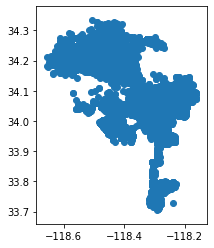

In [49]:
homeless_suspects_gdf.plot()

In [50]:
homeless_suspects_gdf.crs = ({'init': 'epsg:4326'})

In [51]:
homeless_suspects_gdf.to_crs({'init': 'epsg:3310'}, inplace=True)

In [52]:
homeless_suspects_gdf.head()

,record_id,date_reported,date_occurred,time_occurred,division,division_name,reporting_district,part_type,crime_code,crime_code_description,modus_operandi_code,victim_age,victim_sex,victim_descent,premises_code,premises_description,weapon_code,weapon_description,status_code,status_code_description,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,address,cross_street,latitude,longitude,year,quarter,day,month,weekday,monthname,descent_description,hour,minute,geometry,index_right,OBJECTID,CITY
1437675,171304592,01/10/2017,2017-01-10,1530,13,Newton,1391,1,440,Theft plain - petty ($950 & under),2000 1814 1026 2004 0344,20,Female,B,101,Street,nan,NaN,IC,Invest Cont,440,nan,nan,nan,66TH ST,BROADWAY,33.9798,-118.2783,2017,1,10,1,Tuesday,January,Black,15,30,POINT (159090.8307070682 -446963.0160285598),0,1,IN
1437676,170120212,07/20/2017,2017-07-20,1550,1,Central,142,2,740,"Vandalism - felony ($400 & over, all church va...",1402 0329 2004,26,Male,H,101,Street,nan,NaN,AA,Adult Arrest,740,998,nan,nan,INDUSTRIAL,MATEO,34.0519,-118.2531,2017,3,20,7,Thursday,July,Hispanic,15,50,POINT (161271.7805486819 -438924.1341521177),0,1,IN
1437722,170126156,10/03/2017,2017-10-03,1050,1,Central,119,1,440,Theft plain - petty ($950 & under),0344 0910 2004,23,Female,W,215,"Train depot/terminal, other than mta",nan,NaN,IC,Invest Cont,440,nan,nan,nan,800 N ALAMEDA ST,NaN,34.0563,-118.2374,2017,4,3,10,Tuesday,October,White,10,50,POINT (162711.9464918163 -438409.3048102949),0,1,IN
1437732,171600882,06/29/2017,2017-06-29,1400,16,Foothill,1681,1,761,Brandish weapon,0421 0302 2004 1822 1256 0334 1407 1419,26,Male,H,109,Park/playground,101.0,Revolver,AA,Adult Arrest,761,998,nan,nan,ALLEGHENY ST,LAUREL CANYON BL,34.2299,-118.4030,2017,2,29,6,Thursday,June,Hispanic,14,00,POINT (147101.9411395405 -419423.7702617547),0,1,IN
1437800,171109384,04/22/2017,2017-04-22,0800,11,Northeast,1123,2,900,Violation of court order,2004 0561 0432 1202 1236,68,Female,H,210,Restaurant/fast food,nan,NaN,AO,Adult Other,900,nan,nan,nan,3100 GLENDALE BL,NaN,34.1162,-118.2627,2017,2,22,4,Saturday,April,Hispanic,08,00,POINT (160254.9198438759 -431808.6495809895),0,1,IN


In [53]:
homeless_suspects_shelters = gpd.sjoin(homeless_suspects_gdf, dissolvedshelters, op='within')

//anaconda3/lib/python3.7/site-packages/geopandas/tools/sjoin.py:56: UserWarning: CRS of frames being joined does not match!({'init': 'epsg:3310'} != {'init': 'epsg:4326'})
  '(%s != %s)' % (left_df.crs, right_df.crs))


ValueError: 'index_left' and 'index_right' cannot be names in the frames being joined

In [ ]:
crimes_shelters = gpd.sjoin(crimes_clipped, dissolvedshelters, op='within')

In [ ]:
homeless_suspects_shelters.crs = ({'init': 'epsg:4326'})
homeless_suspects_shelters.to_crs({'init': 'epsg:4326'})
crimes_shelters.crs = ({'init': 'epsg:4326'})
crimes_shelters.to_crs({'init': 'epsg:4326'})

In [ ]:
homeless_suspects_shelters.to_file('output/homeless_suspects_shelters.geojson', driver='GeoJSON')

In [ ]:
homeless_suspects_shelters.crs

### Convert buffered shelters back to 4326

In [ ]:
la_shelters.crs = {'init': 'epsg:3310'}

In [ ]:
la_shelters.to_crs({'init': 'epsg:4326'}, inplace=True)

In [ ]:
la_shelters.to_file('output/la_shelters_buffers.geojson', driver='GeoJSON')